# Capítulo 20: La ecuación de ondas

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jfbonder/imc/blob/main/notebooks/11-ondas.ipynb)

Notebook que acompaña al Capítulo 20 (Ecuaciones hiperbólicas: la ecuación de ondas) de *Introducción al Modelado Continuo*. Sigue el orden del texto: el **catálogo de ondas** (viajeras, armónicas, estacionarias, planas y esféricas); la **cuerda vibrante** $u_{tt} = c^2 u_{xx}$ en $(0,L)$ con extremos fijos, resuelta por **series de Fourier** como superposición de modos normales $\sin(k\pi x/L)$ de frecuencias $\omega_k = ck\pi/L$, y su **energía** $E = \int_0^L \bigl(\tfrac12 u_t^2 + \tfrac{c^2}{2}u_x^2\bigr)dx$, que se conserva y se reparte entre los modos; el espectro ideal de una **cuerda pulsada**; la **fórmula de d'Alembert** $u = \tfrac12[g(x-ct) + g(x+ct)] + \tfrac{1}{2c}\int_{x-ct}^{x+ct}h$ en la recta, con el dominio de dependencia y el rango de influencia; y, al final, las **dos descripciones de la misma solución**: la reflexión de un pulso en un extremo fijo vista con la extensión impar.

En cada caso verificamos numéricamente lo que el texto afirma: que la energía total es constante y coincide con la suma por modos $E_k = \frac L4\omega_k^2(A_k^2 + B_k^2)$; que los coeficientes de la cuerda pulsada decaen como $\sin(k\pi x_0/L)/k^2$; que la solución de d'Alembert es nula fuera del dominio de dependencia (velocidad finita de propagación); y que la serie de Fourier, la fórmula de d'Alembert con datos extendidos y el esquema de diferencias finitas `imc.numerico.ondas_leapfrog` (estable si $c\,\Delta t/\Delta x \le 1$) dan la misma solución.

In [1]:
# Configuración (funciona en Colab y en una copia local del repositorio)
try:
    import imc
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/jfbonder/imc.git"], check=True)
    import imc

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon, FancyArrowPatch
from imc import estilo, numerico, espectro
from imc.estilo import COLORES, CICLO

estilo.activar(fuente=14)   # las figuras de un panel van a 0.6\textwidth (~9 cm): fuente grande para que se lean impresas
plt.close(plt.figure())   # inicializa el backend inline fuera de los rc_context de abajo (si no, las figuras no se muestran)
GUARDAR = False   # True para regenerar las figuras de las notas en figuras/


def fuente(F):
    '''Contexto con fuente F en ejes y ticks (leyenda F-2) para las figuras de varios paneles (van a 0.9-0.95\textwidth).'''
    return plt.rc_context({"font.size": F, "axes.labelsize": F, "axes.titlesize": F, "xtick.labelsize": F - 1,
                           "ytick.labelsize": F - 1, "legend.fontsize": F - 2, "lines.linewidth": 2.0})


def flecha(ax, p, q, color="black", lw=2, ms=16, **kw):
    '''Flecha de p a q en coordenadas de datos.'''
    ax.add_patch(FancyArrowPatch(p, q, arrowstyle="-|>", mutation_scale=ms, color=color, lw=lw, shrinkA=0, shrinkB=0, **kw))

## 20.1 Tipos de ondas

*Figura nueva `ondas-esquemas`* (reemplaza a la `\figpendiente` "Distintos tipos de ondas", que pedía fotos): tres esquemas de ondas de la vida cotidiana. (a) Un pulso transversal en una cuerda tensa: la perturbación viaja con velocidad $c$ a lo largo de la cuerda, pero cada punto de la cuerda sólo se mueve en la dirección transversal ($u$). (b) Una onda en la superficie del agua: el perfil sinusoidal avanza mientras el agua queda debajo (y, como el pulso en la cuerda, no viaja con la onda). (c) Una onda electromagnética: los campos $\mathbf E$ y $\mathbf B$ oscilan en planos perpendiculares entre sí y a la dirección de propagación, y no necesitan medio material.

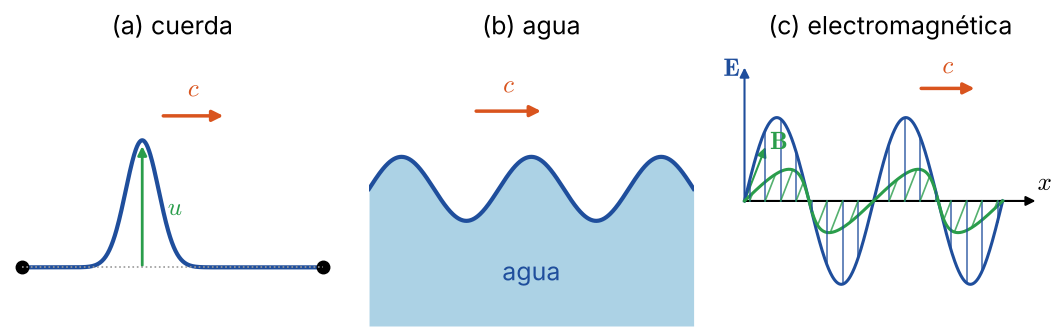

In [2]:
with fuente(18):
    fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(11, 3.7))
    # (a) pulso transversal en una cuerda
    x = np.linspace(0, 10, 500); pulso = 1.3 * np.exp(-(x - 4) ** 2 / 0.6)
    ax1.plot(x, pulso, color=COLORES["traj"], lw=3)
    ax1.plot([0, 10], [0, 0], "o", color="black", ms=9)                                   # extremos fijos
    ax1.plot(x, 0 * x, ":", color="0.6", lw=1.2)
    flecha(ax1, (4.7, 1.55), (6.7, 1.55), color=COLORES["modelo"], lw=2.5); ax1.text(5.7, 1.68, "$c$", color=COLORES["modelo"], ha="center", va="bottom")
    flecha(ax1, (4, 0.02), (4, 1.24), color=COLORES["nul_p"], lw=2, ms=13); ax1.text(4.85, 0.62, "$u$", color=COLORES["nul_p"], ha="left", va="center")
    ax1.set_xlim(-0.4, 10.4); ax1.set_ylim(-0.6, 2.3); ax1.set_title("(a) cuerda")
    # (b) onda en la superficie del agua
    x = np.linspace(0, 10, 500); sup = 0.35 * np.sin(2 * np.pi * x / 4)
    ax2.fill_between(x, -1.5, sup, color="#9ecae1", alpha=0.85, lw=0); ax2.plot(x, sup, color=COLORES["traj"], lw=3)
    ax2.text(5, -0.9, "agua", ha="center", va="center", color=COLORES["traj"])
    flecha(ax2, (3.3, 0.85), (5.3, 0.85), color=COLORES["modelo"], lw=2.5); ax2.text(4.3, 0.98, "$c$", color=COLORES["modelo"], ha="center", va="bottom")
    ax2.set_xlim(0, 10); ax2.set_ylim(-1.5, 1.6); ax2.set_title("(b) agua")
    # (c) onda electromagnética, en proyección oblicua: E vertical (y), B en profundidad (z)
    px = lambda X, Y, Z: (X + 0.6 * Z, Y + 0.38 * Z)
    x = np.linspace(0, 4 * np.pi, 400); E = np.sin(x); B = np.sin(x)
    ax3.plot(*px(x, E, 0 * x), color=COLORES["traj"], lw=2.2); ax3.plot(*px(x, 0 * x, B), color=COLORES["nul_p"], lw=2.2)
    for xi in np.linspace(0.25, 4 * np.pi - 0.25, 17):
        ax3.plot(*px(np.r_[xi, xi], np.r_[0, np.sin(xi)], np.r_[0, 0]), color=COLORES["traj"], lw=1.2, alpha=0.8)
        ax3.plot(*px(np.r_[xi, xi], np.r_[0, 0], np.r_[0, np.sin(xi)]), color=COLORES["nul_p"], lw=1.2, alpha=0.8)
    flecha(ax3, px(0, 0, 0), px(4 * np.pi + 1.6, 0, 0), color="black", lw=1.5, ms=14); ax3.text(*px(4 * np.pi + 1.7, 0.05, 0), "$x$", ha="left", va="bottom")
    flecha(ax3, px(0, 0, 0), px(0, 1.6, 0), color=COLORES["traj"], lw=1.5, ms=14); ax3.text(*px(-0.2, 1.6, 0), r"$\mathbf{E}$", color=COLORES["traj"], ha="right", va="center")
    flecha(ax3, px(0, 0, 0), px(0, 0, 1.7), color=COLORES["nul_p"], lw=1.5, ms=14); ax3.text(*px(0.1, 0, 1.9), r"$\mathbf{B}$", color=COLORES["nul_p"], ha="left", va="center")
    flecha(ax3, px(8.6, 1.35, 0), px(11.2, 1.35, 0), color=COLORES["modelo"], lw=2.5); ax3.text(*px(9.9, 1.45, 0), "$c$", color=COLORES["modelo"], ha="center", va="bottom")
    ax3.set_xlim(-0.8, 15); ax3.set_ylim(-1.5, 1.9); ax3.set_title("(c) electromagnética")
    for ax in (ax1, ax2, ax3): ax.set_axis_off()
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "ondas-esquemas")

*Figura nueva `catalogo-ondas`* (reemplaza a las cinco figuras `viajera`, `armonica`, `estacionaria`, `plana` y `esferica`, que iban a $0.5\,\textwidth$ cada una): (a) una onda viajera $u = g(x - ct)$ con $g$ gaussiana en dos instantes: el perfil se traslada rígidamente $ct$; (b) una onda armónica $u = A\cos(kx - \omega t)$ en dos instantes, con la longitud de onda $\lambda = 2\pi/k$ y la velocidad de fase $c_p = \omega/k$; (c) una onda estacionaria $u = 2A\cos(kx)\cos(\omega t)$ en varios instantes de medio período: los nodos no se mueven y no hay transporte de la perturbación (la figura original rotulaba $t = T/2$ a la cuerda en reposo y $t = T$ a la invertida; los instantes correctos son $T/4$ y $T/2$); (d) una onda plana $\cos(\mathbf k\cdot\mathbf x - \omega t)$ en el plano, con frentes de onda rectos perpendiculares a $\mathbf k$; (e) una onda esférica $\cos(k(r - ct))$, con frentes circulares. Los dos mapas de color comparten la escala.

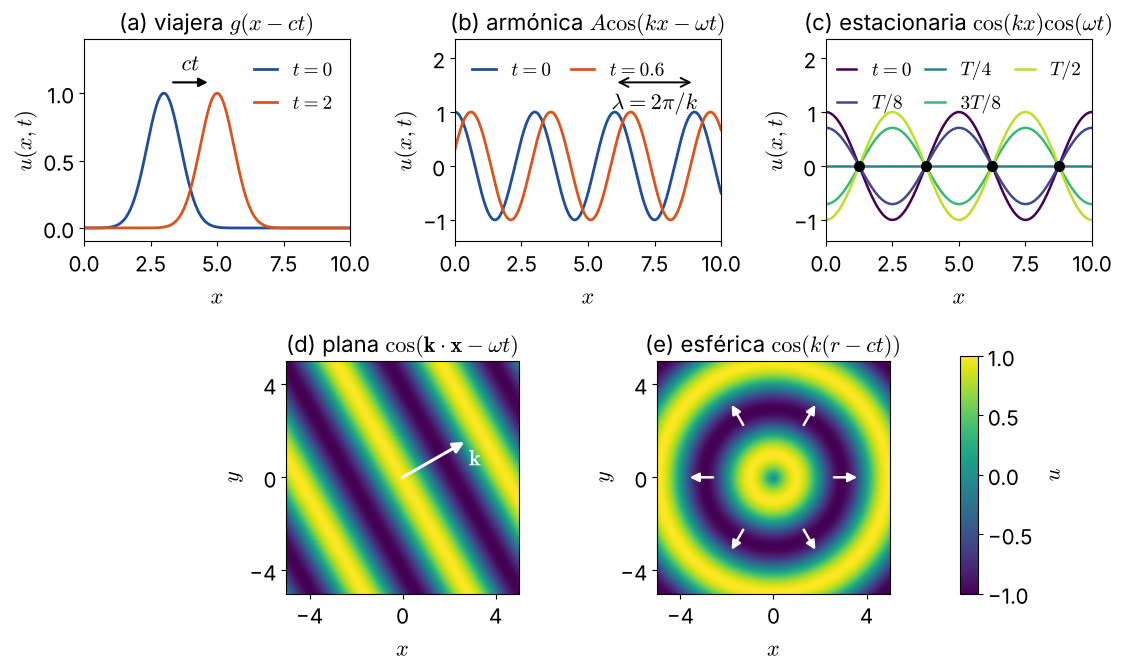

In [3]:
with fuente(16):
    fig = plt.figure(figsize=(12, 6.6))
    gs = fig.add_gridspec(2, 6, height_ratios=[1, 1.15], hspace=0.55, wspace=1.3, left=0.06, right=0.9, top=0.93, bottom=0.09)
    ax1, ax2, ax3 = [fig.add_subplot(gs[0, 2 * i:2 * i + 2]) for i in range(3)]
    ax4, ax5 = fig.add_subplot(gs[1, 1:3]), fig.add_subplot(gs[1, 3:5])
    x = np.linspace(0, 10, 600)
    # (a) viajera: g(x - ct)
    c_v, g_v = 1.0, lambda s: np.exp(-(s - 3) ** 2 / 0.8)
    for t, col in [(0, CICLO[0]), (2, CICLO[1])]:
        ax1.plot(x, g_v(x - c_v * t), color=col, label=f"$t = {t}$")
    flecha(ax1, (3.35, 1.08), (4.65, 1.08), color="black", lw=1.6, ms=13); ax1.text(4.0, 1.13, "$ct$", ha="center", va="bottom")
    ax1.set_ylim(-0.1, 1.4); ax1.set_title("(a) viajera $g(x - ct)$"); ax1.legend(loc="upper right", handlelength=1.2)
    # (b) armónica: A cos(kx - wt), lambda = 2 pi / k, c_p = w / k
    A, k_a, w_a = 1.0, 2 * np.pi / 3, 2 * np.pi / 3
    for t, col in [(0, CICLO[0]), (0.6, CICLO[1])]:
        ax2.plot(x, A * np.cos(k_a * x - w_a * t), color=col, label=f"$t = {t}$")
    ax2.annotate("", (9, 1.55), (6, 1.55), arrowprops=dict(arrowstyle="<->", lw=1.4)); ax2.text(7.5, 1.45, r"$\lambda = 2\pi/k$", ha="center", va="top")
    ax2.set_ylim(-1.4, 2.35); ax2.set_title(r"(b) armónica $A\cos(kx - \omega t)$"); ax2.legend(loc="upper left", ncol=2, handlelength=1.2, columnspacing=1.0)
    # (c) estacionaria: 2A cos(kx) cos(wt), medio período
    k_e, T = 2 * np.pi / 5, 2.0
    for j, (frac, lab) in enumerate([(0, "$t = 0$"), (1 / 8, "$T/8$"), (1 / 4, "$T/4$"), (3 / 8, "$3T/8$"), (1 / 2, "$T/2$")]):
        ax3.plot(x, np.cos(k_e * x) * np.cos(2 * np.pi * frac), color=plt.cm.viridis(frac * 1.8), label=lab, lw=1.8)
    nodos = np.arange(1.25, 10, 2.5); ax3.plot(nodos, 0 * nodos, "o", color="black", ms=7, zorder=5)
    ax3.set_ylim(-1.4, 2.35); ax3.set_title(r"(c) estacionaria $\cos(kx)\cos(\omega t)$"); ax3.legend(loc="upper center", ncol=3, handlelength=1.0, columnspacing=0.7)
    for ax in (ax1, ax2, ax3): ax.set_xlim(0, 10); ax.set_xlabel("$x$"); ax.set_ylabel("$u(x, t)$")
    # (d) plana y (e) esférica en el plano, misma escala de color
    xy = np.linspace(-5, 5, 300); X, Y = np.meshgrid(xy, xy)
    kx, ky = 1.4, 0.8
    im = ax4.pcolormesh(X, Y, np.cos(kx * X + ky * Y), cmap="viridis", vmin=-1, vmax=1, shading="gouraud", rasterized=True)
    flecha(ax4, (0, 0), (1.9 * kx, 1.9 * ky), color="white", lw=2.2, ms=16); ax4.text(1.9 * kx + 0.2, 1.9 * ky - 0.1, r"$\mathbf{k}$", color="white", ha="left", va="top")
    ax4.set_title(r"(d) plana $\cos(\mathbf{k}\cdot\mathbf{x} - \omega t)$")
    R = np.hypot(X, Y)
    ax5.pcolormesh(X, Y, np.cos(1.6 * (R - 1.0)), cmap="viridis", vmin=-1, vmax=1, shading="gouraud", rasterized=True)
    for ang in np.linspace(0, 2 * np.pi, 6, endpoint=False):
        flecha(ax5, (2.6 * np.cos(ang), 2.6 * np.sin(ang)), (3.6 * np.cos(ang), 3.6 * np.sin(ang)), color="white", lw=1.8, ms=13)
    ax5.set_title("(e) esférica $\\cos(k(r - ct))$")
    for ax in (ax4, ax5): ax.set_aspect("equal"); ax.set_xlabel("$x$"); ax.set_ylabel("$y$"); ax.set_xticks([-4, 0, 4]); ax.set_yticks([-4, 0, 4])
    cb = fig.colorbar(im, cax=fig.add_axes([0.79, 0.09, 0.015, 0.36])); cb.set_label("$u$")
    if GUARDAR: estilo.guardar(fig, "catalogo-ondas")

## 20.4 Resolución por series de Fourier

Con extremos fijos, $u(0,t) = u(L,t) = 0$, la solución es la superposición de modos normales
$$u(x,t) = \sum_{k\ge1}\bigl(A_k\cos\omega_k t + B_k\sin\omega_k t\bigr)\sin\frac{k\pi x}{L},\qquad \omega_k = \frac{ck\pi}{L},$$
con $A_k$ los coeficientes de la serie de senos de $g$ y $\omega_k B_k$ los de $h$. Los calculamos como la serie de Fourier de la **extensión impar y $2L$-periódica** de los datos (`imc.espectro.coeficientes_reales`: la extensión impar sólo tiene senos, y sus $b_k$ son exactamente los coeficientes de la serie de senos en $(0,L)$); esa misma extensión reaparece al final con d'Alembert.

**Figura `sol-ondas-20nodos`**: la solución con $L = c = 1$, $h = 0$ y el dato inicial $g(x) = \sin(\pi x) + \tfrac12\sin(3\pi x)$ (el de la figura original: se reconoce por su forma y por la energía total $E = 8.02$ de la Figura `energia-ondas`), truncada a $20$ modos, en varios instantes del primer período $T = 2L/c = 2$. Para este dato la truncación es exacta ($A_1 = 1$, $A_3 = 1/2$ y los demás nulos, como imprimimos), así que la figura muestra la solución exacta: la cuerda pasa por el reposo en $t = T/4$ y se invierte en $t = T/2$.

L = 1.0, c = 1.0, período fundamental T = 2L/c = 2.0; coeficientes A_k del dato (k = 1..20):
   [ 1.  -0.   0.5 -0.   0.  -0.   0.  -0.   0.  -0.   0.  -0.   0.  -0.   0.  -0.   0.  -0.   0.  -0. ]
max |serie(x, 0) - g(x)| = 3.1e-16


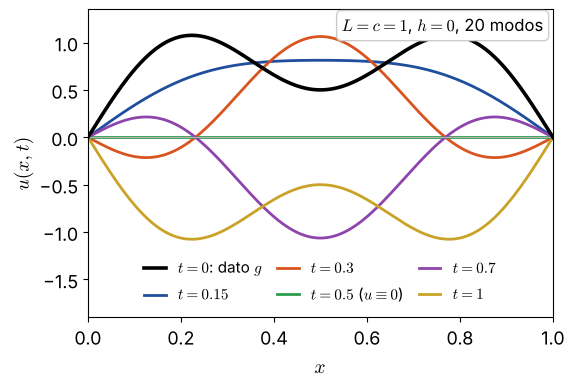

In [4]:
def coef_senos(f, L, N, n=2 ** 14):
    '''Coeficientes b_k (k = 1..N) de la serie de senos sum_k b_k sin(k pi x/L) de f en [0, L]:
    la serie de Fourier de la extensión impar 2L-periódica de f, calculada con imc.espectro.'''
    x = np.arange(n) * 2 * L / n
    f_impar = np.where(x <= L, f(x), -f(2 * L - x))
    k, a, b = espectro.coeficientes_reales(f_impar, 2 * L, N)
    return b[1:]


def serie_ondas(x, t, A, B, c, L, derivada=None):
    '''u(x, t) = sum_k (A_k cos(w_k t) + B_k sin(w_k t)) sin(k pi x / L), o su derivada u_t ("t") o u_x ("x").'''
    k = np.arange(1, len(A) + 1)[:, None]; w = c * k * np.pi / L; X = np.asarray(x, dtype=float)[None, :]
    A = np.asarray(A)[:, None]; B = np.asarray(B)[:, None]
    if derivada == "t":
        return np.sum(w * (-A * np.sin(w * t) + B * np.cos(w * t)) * np.sin(k * np.pi * X / L), axis=0)
    if derivada == "x":
        return np.sum((k * np.pi / L) * (A * np.cos(w * t) + B * np.sin(w * t)) * np.cos(k * np.pi * X / L), axis=0)
    return np.sum((A * np.cos(w * t) + B * np.sin(w * t)) * np.sin(k * np.pi * X / L), axis=0)


L, c, N = 1.0, 1.0, 20
g_ej = lambda x: np.sin(np.pi * x) + 0.5 * np.sin(3 * np.pi * x)
A_ej = coef_senos(g_ej, L, N); B_ej = np.zeros(N)                        # h = 0
omega = c * np.arange(1, N + 1) * np.pi / L
print(f"L = {L}, c = {c}, período fundamental T = 2L/c = {2 * L / c}; coeficientes A_k del dato (k = 1..{N}):")
print("   " + np.array2string(A_ej, precision=4, suppress_small=True, max_line_width=200))
x = np.linspace(0, L, 801)
print(f"max |serie(x, 0) - g(x)| = {np.abs(serie_ondas(x, 0, A_ej, B_ej, c, L) - g_ej(x)).max():.1e}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, g_ej(x), color="black", lw=2.6, label="$t = 0$: dato $g$", zorder=5)
for t, col in zip([0.15, 0.3, 0.5, 0.7, 1.0], CICLO):
    ax.plot(x, serie_ondas(x, t, A_ej, B_ej, c, L), color=col, lw=2, label=f"$t = {t:g}$" + (" ($u \\equiv 0$)" if t == 0.5 else ""))
ax.axhline(0, color="0.7", lw=0.8)
ax.set_xlabel("$x$"); ax.set_ylabel("$u(x, t)$"); ax.set_xlim(0, L); ax.set_ylim(-1.9, 1.35); ax.legend(loc="lower center", fontsize=11, ncol=3, columnspacing=1.0, handlelength=1.4)
estilo.parametros(ax, f"$L = c = 1$, $h = 0$, {N} modos", loc="upper right", fontsize=12)
if GUARDAR: estilo.guardar(fig, "sol-ondas-20nodos")

**Figura `energia-ondas`**: la energía cinética $E_{cin} = \int_0^L\tfrac12 u_t^2$, la potencial $E_{pot} = \int_0^L\tfrac{c^2}2 u_x^2$ y la total de esa solución, calculadas integrando numéricamente (regla del trapecio en $801$ puntos) las derivadas de la serie. La total es constante, y coincide con la suma por modos del texto (Sección 20.4, "La energía repartida entre los modos"),
$$E = \sum_k E_k,\qquad E_k = \frac L4\,\omega_k^2\bigl(A_k^2 + B_k^2\bigr),$$
que aquí da $E_1 = \pi^2/4$ y $E_3 = 9\pi^2/16$. Fijate que la energía se intercambia entre cinética y potencial (con la frecuencia $2\omega_1$ del modo fundamental, modulada por el tercer modo) pero cada $E_k$ es constante por separado.

E total: mínimo 8.019054, máximo 8.019054 (variación relativa 6.6e-16)
suma por modos sum_k E_k = 8.019054   (E_1 = pi^2/4 = 2.467401, E_3 = 9 pi^2/16 = 5.551652)
E_cin(0) = 0.0e+00, E_cin(T/2) = 7.9e-31 (cuerda en reposo instantáneo), máximo 8.0191 en t = 0.500 (T/4, cuerda plana); E_pot(0) = 8.0191


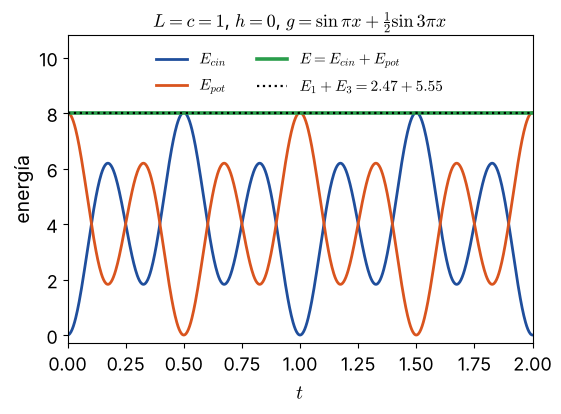

In [5]:
ts = np.linspace(0, 2, 801)
E_cin = np.array([np.trapezoid(0.5 * serie_ondas(x, t, A_ej, B_ej, c, L, "t") ** 2, x) for t in ts])
E_pot = np.array([np.trapezoid(0.5 * c ** 2 * serie_ondas(x, t, A_ej, B_ej, c, L, "x") ** 2, x) for t in ts])
E_tot = E_cin + E_pot
E_k = L / 4 * omega ** 2 * (A_ej ** 2 + B_ej ** 2)
print(f"E total: mínimo {E_tot.min():.6f}, máximo {E_tot.max():.6f} (variación relativa {(E_tot.max() - E_tot.min()) / E_tot.mean():.1e})")
print(f"suma por modos sum_k E_k = {E_k.sum():.6f}   (E_1 = pi^2/4 = {np.pi ** 2 / 4:.6f}, E_3 = 9 pi^2/16 = {9 * np.pi ** 2 / 16:.6f})")
print(f"E_cin(0) = {E_cin[0]:.1e}, E_cin(T/2) = {E_cin[400]:.1e} (cuerda en reposo instantáneo), máximo {E_cin.max():.4f} en t = {ts[E_cin.argmax()]:.3f} (T/4, cuerda plana); E_pot(0) = {E_pot[0]:.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(ts, E_cin, color=CICLO[0], lw=2, label="$E_{cin}$")
ax.plot(ts, E_pot, color=CICLO[1], lw=2, label="$E_{pot}$")
ax.plot(ts, E_tot, color=CICLO[2], lw=2.6, label="$E = E_{cin} + E_{pot}$")
ax.axhline(E_k.sum(), color="black", ls=":", lw=1.6, label=f"$E_1 + E_3 = {E_k[0]:.2f} + {E_k[2]:.2f}$")
ax.set_xlabel("$t$"); ax.set_ylabel("energía"); ax.set_xlim(0, 2); ax.set_ylim(-0.3, 10.8); ax.legend(loc="upper center", ncol=2, fontsize=11)
ax.set_title(r"$L = c = 1$, $h = 0$, $g = \sin\pi x + \frac{1}{2}\sin 3\pi x$", fontsize=13)
if GUARDAR: estilo.guardar(fig, "energia-ondas")

## Volvemos al problema: la cuerda vibrante

La cuerda de longitud $L$, tensión $T$ y densidad $\rho$ vibra con las frecuencias $f_k = \omega_k/2\pi = \frac{k}{2L}\sqrt{T/\rho} = k f_1$: todos los armónicos son múltiplos enteros de la fundamental. El timbre es el reparto de la energía entre los modos, y depende de cómo se excita la cuerda. Para la **cuerda pulsada** en $x_0$ (forma inicial triangular de altura $a$, $h = 0$) el texto afirma $A_k\propto\sin(k\pi x_0/L)/k^2$; la fórmula exacta (ejercicio de la cuerda pulsada y golpeada) es
$$A_k = \frac{2aL^2}{\pi^2 x_0(L - x_0)}\,\frac{\sin(k\pi x_0/L)}{k^2}.$$
La comprobamos con `coef_senos` para $x_0 = L/5$: los coeficientes decaen como $1/k^2$ y faltan los múltiplos de $5$ (el punto de pulsado es un nodo de esos modos, así que no se pueden excitar desde ahí). Para la cuerda golpeada ($g = 0$, $h$ concentrada en $x_0$) los $B_k\propto\sin(k\pi x_0/L)/k$ decaen más lento: más armónicos altos, otro timbre.

In [6]:
x0, a = L / 5, 1.0
g_pulsada = lambda x: np.where(x <= x0, a * x / x0, a * (L - x) / (L - x0))
N_p = 25
A_pul = coef_senos(g_pulsada, L, N_p)
kk = np.arange(1, N_p + 1)
A_teo = 2 * a * L ** 2 / (np.pi ** 2 * x0 * (L - x0)) * np.sin(kk * np.pi * x0 / L) / kk ** 2
print(f"cuerda pulsada en x0 = L/5 = {x0}: max |A_k numérico - fórmula| = {np.abs(A_pul - A_teo).max():.1e}")
print("   k   :", " ".join(f"{k:6d}" for k in kk[:10]))
print("   A_k :", " ".join(f"{v:6.3f}" for v in A_pul[:10]))
print(f"   |A_k| k^2 / |A_1| en k = 1, 2, 3, 4, 6: {np.round(np.abs(A_pul[[0, 1, 2, 3, 5]]) * kk[[0, 1, 2, 3, 5]] ** 2 / abs(A_pul[0]), 3)}  (= |sin(k pi/5)| / sin(pi/5))")
print(f"   A_5, A_10, A_15, A_20 = {np.round(A_pul[[4, 9, 14, 19]], 6)}  (ausentes)")
E_pul = L / 4 * (c * kk * np.pi / L) ** 2 * A_pul ** 2
print(f"   fracción de la energía en el modo fundamental: {E_pul[0] / E_pul.sum():.3f}; en los modos k >= 6: {E_pul[5:].sum() / E_pul.sum():.3f} (E_k ~ 1/k^2)")
# la cuerda golpeada: h concentrada en x0 -> B_k = 2 sin(k pi x0/L) / (c k pi) (por unidad de impulso)
B_gol = 2 * np.sin(kk * np.pi * x0 / L) / (c * kk * np.pi)
print(f"cuerda golpeada en x0: |B_k| k / |B_1| en k = 1..4: {np.round(np.abs(B_gol[:4]) * kk[:4] / abs(B_gol[0]), 3)} (decaen como 1/k)")

cuerda pulsada en x0 = L/5 = 0.2: max |A_k numérico - fórmula| = 6.5e-09
   k   :      1      2      3      4      5      6      7      8      9     10
   A_k :  0.744  0.301  0.134  0.047  0.000 -0.021 -0.025 -0.019 -0.009 -0.000
   |A_k| k^2 / |A_1| en k = 1, 2, 3, 4, 6: [1.    1.618 1.618 1.    1.   ]  (= |sin(k pi/5)| / sin(pi/5))
   A_5, A_10, A_15, A_20 = [ 0. -0.  0. -0.]  (ausentes)
   fracción de la energía en el modo fundamental: 0.449; en los modos k >= 6: 0.099 (E_k ~ 1/k^2)
cuerda golpeada en x0: |B_k| k / |B_1| en k = 1..4: [1.    1.618 1.618 1.   ] (decaen como 1/k)


*Figura nueva `modos-cuerda`* (iría en el "Volvemos al problema: la cuerda vibrante", junto a la fórmula de $f_k$): (a) los primeros cuatro modos normales $\sin(k\pi x/L)$ con sus frecuencias $f_k = kf_1$ y sus nodos; el punto de pulsado $x_0 = L/5$ está marcado. (b) El espectro ideal de la cuerda pulsada en $x_0 = L/5$: las amplitudes $|A_k|$ en función de $k$ (es decir, de la frecuencia $f_k = kf_1$), con la envolvente $\propto 1/k^2$; los armónicos $k = 5, 10, 15, 20$ están ausentes. Es el espectro que el modelo predice para la grabación de una cuerda pulsada; lo que se mide en el laboratorio se le parece, con los picos ligeramente corridos (inarmonicidad) y decayendo en el tiempo.

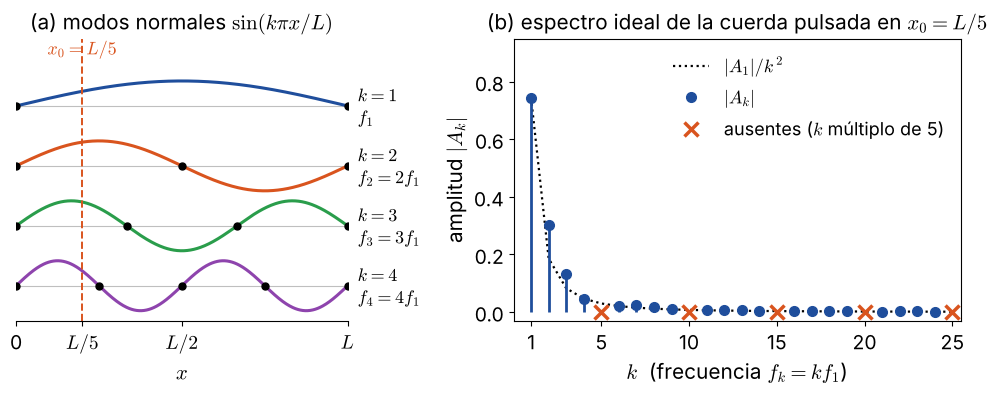

In [7]:
with fuente(15):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.2), gridspec_kw=dict(width_ratios=[1, 1.35]))
    xm = np.linspace(0, L, 400)
    for k in range(1, 5):
        y0 = (4 - k) * 2.4
        ax1.plot(xm, y0 + np.sin(k * np.pi * xm / L), color=CICLO[k - 1], lw=2.2)
        ax1.axhline(y0, color="0.75", lw=0.8, zorder=0)
        nodos = np.arange(0, k + 1) * L / k
        ax1.plot(nodos, y0 + 0 * nodos, "o", color="black", ms=5, zorder=5)
        ax1.text(L + 0.03, y0, f"$k = {k}$\n$f_{k} = {k}f_1$" if k > 1 else "$k = 1$\n$f_1$", va="center", ha="left", fontsize=13)
    ax1.axvline(x0, color=COLORES["modelo"], ls="--", lw=1.4); ax1.text(x0, 9.05, "$x_0 = L/5$", color=COLORES["modelo"], ha="center", va="bottom", fontsize=13)
    ax1.set_xlim(0, L); ax1.set_ylim(-1.4, 9.9); ax1.set_yticks([]); ax1.set_xticks([0, x0, L / 2, L], ["0", "$L/5$", "$L/2$", "$L$"]); ax1.set_xlabel("$x$")
    ax1.set_title("(a) modos normales $\\sin(k\\pi x/L)$", fontsize=15)
    for s in ["top", "right", "left"]: ax1.spines[s].set_visible(False)
    ausentes = kk % 5 == 0
    ax2.plot(kk, np.abs(A_teo[0]) / kk ** 2, ":", color="black", lw=1.6, label="$|A_1|/k^2$")
    ml, sl, bl = ax2.stem(kk[~ausentes], np.abs(A_pul[~ausentes]), linefmt="-", markerfmt="o", basefmt=" ")
    plt.setp(sl, color=COLORES["dato"], lw=2); plt.setp(ml, color=COLORES["dato"], ms=7); ml.set_label("$|A_k|$")
    ax2.plot(kk[ausentes], 0 * kk[ausentes], "x", color=COLORES["modelo"], ms=10, mew=2.5, label="ausentes ($k$ múltiplo de 5)")
    ax2.set_xlabel("$k$  (frecuencia $f_k = k f_1$)"); ax2.set_ylabel("amplitud $|A_k|$"); ax2.set_xlim(0, N_p + 0.5); ax2.set_ylim(-0.03, 0.95); ax2.set_xticks([1, 5, 10, 15, 20, 25])
    ax2.set_title("(b) espectro ideal de la cuerda pulsada en $x_0 = L/5$", fontsize=15); ax2.legend(loc="upper right")
    fig.tight_layout()
    if GUARDAR: estilo.guardar(fig, "modos-cuerda")

## 20.5 La fórmula de d'Alembert

En toda la recta, $u(x,t) = \tfrac12\bigl(g(x-ct) + g(x+ct)\bigr) + \tfrac1{2c}\int_{x-ct}^{x+ct}h(s)\,ds$: la mitad del dato viaja hacia cada lado. La implementamos con una antiderivada $H$ de $h$ ($\int_{x-ct}^{x+ct}h = H(x+ct) - H(x-ct)$). *Figura nueva `dalembert-pulso`* (iría junto a la fórmula de d'Alembert, Sección 20.5): un pulso inicial $g$ gaussiano angosto con $h = 0$ se parte en dos mitades $g(x\mp ct)/2$ que viajan en sentidos opuestos con velocidad $c$; cuatro instantes apilados. Los perfiles no se deforman, y nada pasa fuera de $|x - x_0| \le ct + $ (ancho del pulso).

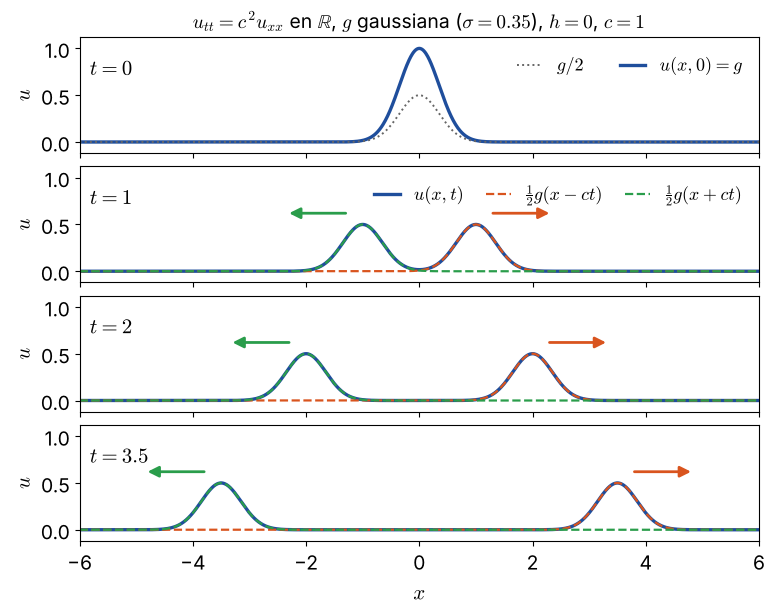

In [8]:
def dalembert(x, t, g, H, c):
    '''Fórmula de d'Alembert: g dato inicial, H antiderivada de la velocidad inicial h (H' = h).'''
    return 0.5 * (g(x - c * t) + g(x + c * t)) + (H(x + c * t) - H(x - c * t)) / (2 * c)


c_d, sigma = 1.0, 0.35
g_d = lambda s: np.exp(-s ** 2 / (2 * sigma ** 2))
H_cero = lambda s: 0.0 * s
xr = np.linspace(-6, 6, 1201)
instantes = [0, 1, 2, 3.5]
with fuente(15):
    fig, axs = plt.subplots(len(instantes), 1, figsize=(8, 6.4), sharex=True)
    for ax, t in zip(axs, instantes):
        u = dalembert(xr, t, g_d, H_cero, c_d)
        ax.plot(xr, u, color=COLORES["traj"], lw=2.4, label="$u(x,t)$" if t == instantes[1] else None)
        if t > 0:
            ax.plot(xr, 0.5 * g_d(xr - c_d * t), "--", color=COLORES["modelo"], lw=1.6, label=r"$\frac{1}{2} g(x - ct)$" if t == instantes[1] else None)
            ax.plot(xr, 0.5 * g_d(xr + c_d * t), "--", color=COLORES["nul_p"], lw=1.6, label=r"$\frac{1}{2} g(x + ct)$" if t == instantes[1] else None)
            flecha(ax, (c_d * t + 0.3, 0.62), (c_d * t + 1.3, 0.62), color=COLORES["modelo"], lw=2); flecha(ax, (-c_d * t - 0.3, 0.62), (-c_d * t - 1.3, 0.62), color=COLORES["nul_p"], lw=2)
        else:
            ax.plot(xr, 0.5 * g_d(xr), ":", color="0.4", lw=1.4, label="$g/2$"); ax.plot([], [], color=COLORES["traj"], lw=2.4, label="$u(x, 0) = g$"); ax.legend(loc="upper right", ncol=2, handlelength=1.4)
        ax.text(0.015, 0.85, f"$t = {t:g}$", transform=ax.transAxes, ha="left", va="top")
        ax.set_ylim(-0.12, 1.12); ax.set_yticks([0, 0.5, 1]); ax.set_ylabel("$u$")
    axs[1].legend(loc="upper right", ncol=3, handlelength=1.4, columnspacing=1.2)
    axs[-1].set_xlabel("$x$"); axs[-1].set_xlim(-6, 6)
    axs[0].set_title(f"$u_{{tt}} = c^2 u_{{xx}}$ en $\\mathbb{{R}}$, $g$ gaussiana ($\\sigma = {sigma}$), $h = 0$, $c = {c_d:g}$", fontsize=14)
    fig.tight_layout(h_pad=0.4)
    if GUARDAR: estilo.guardar(fig, "dalembert-pulso")

**Dominio de dependencia y rango de influencia.** *Figura nueva `caracteristicas`* (reemplaza a `dominio-dependencia` y `rango-influencia`, que iban a $0.6\,\textwidth$ cada una): (a) el valor $u(x_0,t_0)$ sólo depende de los datos en $[x_0 - ct_0, x_0 + ct_0]$, la base del triángulo característico limitado por las rectas $x \pm ct = x_0 \pm ct_0$; (b) el dato en $(x_0, 0)$ sólo influye en el cono $|x - x_0|\le ct$. Ambos con $c = 1$.

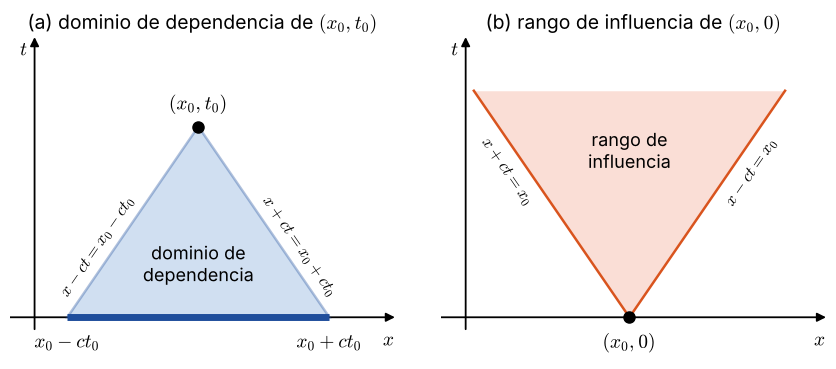

In [9]:
def plano_xt(ax, xlim=(-0.3, 4.4), tlim=(-0.35, 2.35)):
    '''Ejes x, t dibujados como flechas desde el origen, sin marco.'''
    ax.set_axis_off(); ax.set_xlim(*xlim); ax.set_ylim(*tlim)
    flecha(ax, (xlim[0], 0), (xlim[1], 0), lw=1.3, ms=13); flecha(ax, (0, tlim[0] + 0.25), (0, tlim[1]), lw=1.3, ms=13)
    ax.text(xlim[1], -0.08, "$x$", ha="right", va="top"); ax.text(-0.08, tlim[1], "$t$", ha="right", va="top")


def angulo(ax, dx, dt):
    '''Ángulo en pantalla (grados) de la recta de pendiente dt/dx en el plano (x, t).'''
    p = ax.transData.transform([(0, 0), (dx, dt)])
    a = np.degrees(np.arctan2(p[1, 1] - p[0, 1], p[1, 0] - p[0, 0]))
    return a - 180 if a > 90 else a


x0_c, t0_c, c_c = 2.0, 1.6, 1.0
with fuente(14):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8.5, 3.7))
    fig.subplots_adjust(left=0.02, right=0.98, top=0.9, bottom=0.03, wspace=0.12)
    # (a) dominio de dependencia de (x0, t0)
    plano_xt(ax1)
    xa, xb = x0_c - c_c * t0_c, x0_c + c_c * t0_c
    ax1.add_patch(Polygon([(xa, 0), (xb, 0), (x0_c, t0_c)], closed=True, fc=COLORES["traj2"], alpha=0.35, ec=COLORES["traj"], lw=1.8))
    ax1.plot([xa, xb], [0, 0], color=COLORES["traj"], lw=5, solid_capstyle="butt")
    ax1.plot(x0_c, t0_c, "o", color="black", ms=8, zorder=5); ax1.text(x0_c, t0_c + 0.1, "$(x_0, t_0)$", ha="center", va="bottom")
    ax1.text(xa, -0.1, "$x_0 - ct_0$", ha="center", va="top"); ax1.text(xb, -0.1, "$x_0 + ct_0$", ha="center", va="top")
    ax1.text(x0_c, 0.45, "dominio de\ndependencia", ha="center", va="center", fontsize=13)
    ax1.text(x0_c - 0.4 * c_c * t0_c - 0.1, 0.6 * t0_c, "$x - ct = x_0 - ct_0$", rotation=angulo(ax1, c_c, 1), ha="right", va="bottom", fontsize=12, rotation_mode="anchor")
    ax1.text(x0_c + 0.4 * c_c * t0_c + 0.1, 0.6 * t0_c, "$x + ct = x_0 + ct_0$", rotation=angulo(ax1, -c_c, 1), ha="left", va="bottom", fontsize=12, rotation_mode="anchor")
    ax1.set_title("(a) dominio de dependencia de $(x_0, t_0)$")
    # (b) rango de influencia de (x0, 0): cono abierto hacia arriba
    plano_xt(ax2)
    tt = np.linspace(0, 1.9, 50)
    ax2.fill_betweenx(tt, x0_c - c_c * tt, x0_c + c_c * tt, color="#f4b6a6", alpha=0.45, lw=0)
    ax2.plot(x0_c - c_c * tt, tt, color=COLORES["modelo"], lw=1.8); ax2.plot(x0_c + c_c * tt, tt, color=COLORES["modelo"], lw=1.8)
    ax2.plot(x0_c, 0, "o", color="black", ms=8, zorder=5); ax2.text(x0_c, -0.1, "$(x_0, 0)$", ha="center", va="top")
    ax2.text(x0_c, 1.4, "rango de\ninfluencia", ha="center", va="center", fontsize=13)
    ax2.text(x0_c - 0.5 * c_c * 2.0 - 0.1, 1.0, "$x + ct = x_0$", rotation=angulo(ax2, -c_c, 1), ha="right", va="top", fontsize=12, rotation_mode="anchor")
    ax2.text(x0_c + 0.5 * c_c * 2.0 + 0.1, 1.0, "$x - ct = x_0$", rotation=angulo(ax2, c_c, 1), ha="left", va="top", fontsize=12, rotation_mode="anchor")
    ax2.set_title("(b) rango de influencia de $(x_0, 0)$")
    if GUARDAR: estilo.guardar(fig, "caracteristicas")

**Verificación: velocidad finita de propagación.** Con datos $g$ y $h$ soportados en $[-1, 1]$ (ahora $h\ne0$), la solución de d'Alembert en el instante $t$ es nula fuera de $[-1 - ct, 1 + ct]$: el punto $(x,t)$ con $|x| > 1 + ct$ tiene su dominio de dependencia fuera del soporte de los datos. Adentro, en cambio, la parte de $h$ deja una "estela" constante $\frac1{2c}\int h$ entre los dos frentes (en dimensión $1$ no vale el principio de Huygens fuerte): lo imprimimos.

In [10]:
bump = lambda s: np.where(np.abs(s) < 1, (1 - s ** 2) ** 2, 0.0)           # g = h = bump, soporte [-1, 1]
s_fino = np.linspace(-30, 30, 120001)
H_bump = lambda s: np.interp(s, s_fino, np.concatenate([[0], np.cumsum(0.5 * (bump(s_fino[1:]) + bump(s_fino[:-1])) * np.diff(s_fino))]))
xv = np.linspace(-12, 12, 4801)
print(f"int h ds = {H_bump(30.0) - H_bump(-30.0):.5f} (exacto 16/15 = {16 / 15:.5f});  estela esperada (1/2c) int h = {(16 / 15) / (2 * c_d):.5f}")
for t in [0.5, 2, 5, 8]:
    u = dalembert(xv, t, bump, H_bump, c_d)
    afuera = np.abs(xv) > 1 + c_d * t + 1e-9
    adentro = np.abs(xv) < c_d * t - 1
    print(f"t = {t:3g}: max |u| fuera de [-1 - ct, 1 + ct] = {np.abs(u[afuera]).max():.1e};  max |u| = {np.abs(u).max():.4f};" + (f"  u entre los frentes (|x| < ct - 1): min {u[adentro].min():.5f}, max {u[adentro].max():.5f}" if adentro.any() else ""))

int h ds = 1.06667 (exacto 16/15 = 1.06667);  estela esperada (1/2c) int h = 0.53333
t = 0.5: max |u| fuera de [-1 - ct, 1 + ct] = 0.0e+00;  max |u| = 0.9854;
t =   2: max |u| fuera de [-1 - ct, 1 + ct] = 0.0e+00;  max |u| = 0.8262;  u entre los frentes (|x| < ct - 1): min 0.53333, max 0.53333
t =   5: max |u| fuera de [-1 - ct, 1 + ct] = 0.0e+00;  max |u| = 0.8262;  u entre los frentes (|x| < ct - 1): min 0.53333, max 0.53333
t =   8: max |u| fuera de [-1 - ct, 1 + ct] = 0.0e+00;  max |u| = 0.8262;  u entre los frentes (|x| < ct - 1): min 0.53333, max 0.53333


## 20.6 Dos descripciones de la misma solución

El problema en $(0,L)$ con extremos fijos se resuelve con la fórmula de d'Alembert aplicada a las **extensiones impares y $2L$-periódicas** $\tilde g$, $\tilde h$ de los datos: la solución resultante es impar y $2L$-periódica en $x$, así que se anula en $x = 0$ y $x = L$, y por unicidad coincide con la serie de Fourier. Tomamos un pulso gaussiano angosto centrado en $x_0 = 0.6$ que viaja hacia la derecha ($h = -cg'$, para que en $(0,L)$ sea inicialmente $u = g(x - ct)$), con $L = c = 1$: llega al extremo $x = L$ en $t = (L - x_0)/c = 0.4$. Su imagen en $(L, 2L)$ es el pulso invertido $-g(2L - x)$, que viaja hacia la *izquierda* (la extensión impar de $h$ invierte el sentido) y entra en $(0,L)$ justo cuando el pulso original sale: eso es la reflexión con cambio de signo.

Verificamos que las tres descripciones coinciden: d'Alembert con datos extendidos, la serie de Fourier con $N = 150$ modos ($A_k$ y $B_k = \frac{1}{\omega_k}\times$ coeficiente de $h$) y el esquema leapfrog `numerico.ondas_leapfrog` con $\Delta x = 1/500$ y $r = c\,\Delta t/\Delta x = 0.5$ y $r = 1$.

In [11]:
def extension_impar(f, L):
    '''Extensión impar y 2L-periódica de una función f dada en [0, L].'''
    def f_ext(x):
        y = np.mod(x, 2 * L)
        return np.where(y <= L, f(y), -f(2 * L - y))
    return f_ext


def antiderivada_periodica(h_ext, L, n=40001):
    '''H con H' = h_ext (h_ext impar y 2L-periódica, de integral nula en un período), H(0) = 0, evaluada por interpolación.'''
    s = np.linspace(0, 2 * L, n); hs = h_ext(s)
    Hs = np.concatenate([[0], np.cumsum(0.5 * (hs[1:] + hs[:-1]) * np.diff(s))])
    return lambda x: np.interp(np.mod(x, 2 * L), s, Hs)


x0_r, sig_r = 0.6, 0.05
g_r = lambda s: np.exp(-(s - x0_r) ** 2 / (2 * sig_r ** 2))
h_r = lambda s: c * (s - x0_r) / sig_r ** 2 * g_r(s)                     # h = -c g': pulso que viaja hacia la derecha
g_ext, h_ext = extension_impar(g_r, L), extension_impar(h_r, L)
H_ext = antiderivada_periodica(h_ext, L)
u_dal = lambda x, t: dalembert(x, t, g_ext, H_ext, c)

# serie de Fourier: A_k de g, B_k = (coeficiente seno de h) / omega_k
N_r = 150
A_r = coef_senos(g_r, L, N_r); B_r = coef_senos(h_r, L, N_r) / (c * np.arange(1, N_r + 1) * np.pi / L)
u_ser = lambda x, t: serie_ondas(x, t, A_r, B_r, c, L)
print(f"pulso en x0 = {x0_r}, sigma = {sig_r}: llega a x = L en t = {(L - x0_r) / c:g}")
print(f"d'Alembert con datos extendidos: max |u(0, t)|, |u(L, t)| para t en [0, 2] = {max(np.abs(u_dal(np.array([0.0, L]), t)).max() for t in np.linspace(0, 2, 201)):.1e}  (extremos fijos)")
print(f"serie de Fourier con {N_r} modos: max |serie(x, 0) - g(x)| = {np.abs(u_ser(xg := np.linspace(0, L, 501), 0) - g_r(xg)).max():.1e}; |A_k| > 1e-8 sólo hasta k = {np.max(np.nonzero(np.abs(A_r) > 1e-8)) + 1}")

pulso en x0 = 0.6, sigma = 0.05: llega a x = L en t = 0.4
d'Alembert con datos extendidos: max |u(0, t)|, |u(L, t)| para t en [0, 2] = 1.3e-14  (extremos fijos)
serie de Fourier con 150 modos: max |serie(x, 0) - g(x)| = 1.2e-14; |A_k| > 1e-8 sólo hasta k = 36


**Las tres descripciones coinciden.** El esquema leapfrog con $\Delta x = 1/500$: con $r = 0.5$ el error es de $10^{-3}$ (dispersión numérica del esquema, de orden $\Delta x^2$); con $r = 1$ el esquema traslada exactamente los valores de la grilla (es la fórmula de d'Alembert discreta) y el único error es el del primer paso.

In [12]:
# leapfrog con dx = 1/500, r = 0.5 y r = 1
dx = L / 500; xg = np.arange(0, L + dx / 2, dx)
instantes_r = [0, 0.2, 0.35, 0.45, 0.7]
sol_lf = {}
for r in [0.5, 1.0]:
    dt = r * dx / c
    sol_lf[r] = (dt, numerico.ondas_leapfrog(g_r(xg), h_r(xg), c, dx, dt, int(round(0.7 / dt))))
print(f"{'t':>4s} {'max|dAlembert - serie|':>24s} {'max|dAlembert - leapfrog r=0.5|':>32s} {'r=1':>10s}")
for t in instantes_r:
    ud, us = u_dal(xg, t), u_ser(xg, t)
    errs = [np.abs(ud - sol_lf[r][1][int(round(t / sol_lf[r][0]))]).max() for r in [0.5, 1.0]]
    print(f"{t:4g} {np.abs(ud - us).max():24.1e} {errs[0]:32.1e} {errs[1]:10.1e}")
print(f"(max |u| = {np.abs(u_dal(xg, 0)).max():.2f}; con r = 1 el leapfrog traslada exactamente, salvo el primer paso)")

   t   max|dAlembert - serie|  max|dAlembert - leapfrog r=0.5|        r=1
   0                  1.2e-14                          0.0e+00    0.0e+00
 0.2                  4.2e-08                          3.0e-04    1.3e-04


0.35                  5.9e-08                          4.1e-04    1.9e-04
0.45                  5.9e-08                          4.7e-04    1.9e-04
 0.7                  4.2e-08                          9.9e-04    1.3e-04
(max |u| = 1.00; con r = 1 el leapfrog traslada exactamente, salvo el primer paso)


*Figura nueva `reflexion-pulso`* (es la `\figpendiente` de la Sección 20.6): instantes sucesivos de la solución. En $[0, L]$ (fondo blanco) la solución del problema en el intervalo; en $(L, 2L)$ (fondo gris, trazos) la extensión impar, que es lo que la fórmula de d'Alembert "ve" del otro lado del extremo fijo. El pulso llega a $x = L$ en $t = 0.4$, se cruza con su imagen invertida ($t = 0.35$ y $0.45$: en $x = L$ los dos se cancelan siempre, y en $t = 0.4$ se cancelan en todo $[0, L]$, con toda la energía en forma cinética) y en $t = 0.7$ vuelve invertido y hacia la izquierda.

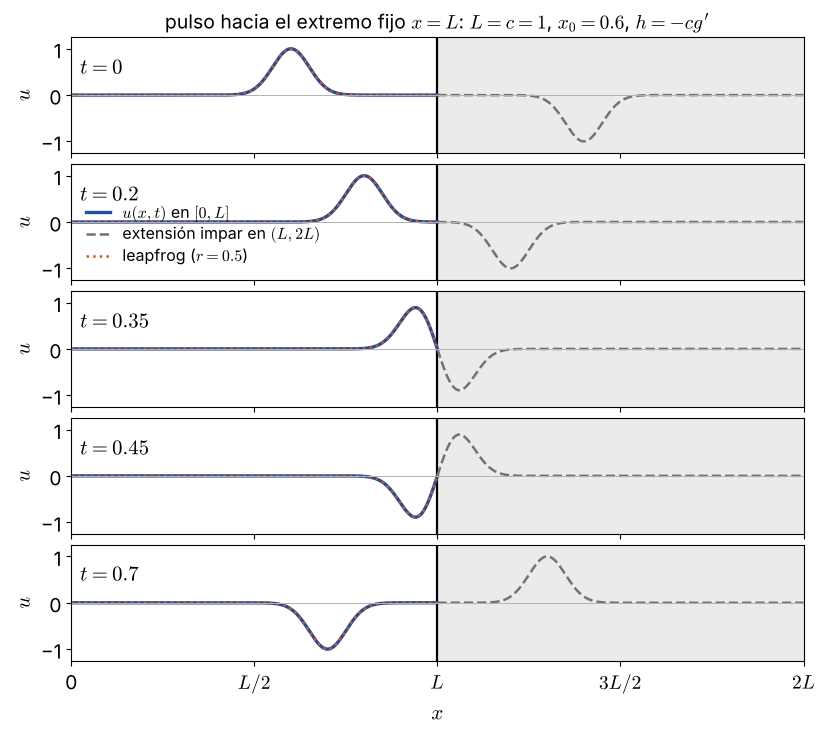

In [13]:
x2 = np.linspace(0, 2 * L, 1601)
with fuente(15):
    fig, axs = plt.subplots(len(instantes_r), 1, figsize=(8.5, 7.6), sharex=True)
    for ax, t in zip(axs, instantes_r):
        u = u_dal(x2, t)
        ax.axvspan(L, 2 * L, color="0.92", lw=0)
        ax.axvline(L, color="black", lw=1.6)
        ax.plot(x2[x2 <= L], u[x2 <= L], color=COLORES["traj"], lw=2.4, label="$u(x, t)$ en $[0, L]$" if t == instantes_r[1] else None)
        ax.plot(x2[x2 >= L], u[x2 >= L], "--", color="0.45", lw=1.8, label="extensión impar en $(L, 2L)$" if t == instantes_r[1] else None)
        ax.plot(xg, sol_lf[0.5][1][int(round(t / sol_lf[0.5][0]))], ":", color=COLORES["modelo"], lw=1.8, label="leapfrog ($r = 0.5$)" if t == instantes_r[1] else None)
        ax.axhline(0, color="0.7", lw=0.7)
        ax.text(0.012, 0.86, f"$t = {t:g}$", transform=ax.transAxes, ha="left", va="top")
        ax.set_ylim(-1.25, 1.25); ax.set_yticks([-1, 0, 1]); ax.set_ylabel("$u$")
    axs[1].legend(loc="lower left", ncol=1, handlelength=1.5, fontsize=11.5, labelspacing=0.15)
    axs[0].set_title(f"pulso hacia el extremo fijo $x = L$: $L = c = 1$, $x_0 = {x0_r}$, $h = -cg'$", fontsize=14)
    axs[-1].set_xlabel("$x$"); axs[-1].set_xlim(0, 2 * L); axs[-1].set_xticks([0, 0.5, 1, 1.5, 2], ["0", "$L/2$", "$L$", "$3L/2$", "$2L$"])
    fig.tight_layout(h_pad=0.3)
    if GUARDAR: estilo.guardar(fig, "reflexion-pulso")

**La condición CFL.** El esquema centrado es estable sólo si $r = c\,\Delta t/\Delta x \le 1$: el dominio de dependencia numérico ($\Delta x$ por paso) debe contener al de la ecuación ($c\,\Delta t$ por paso). Si $r > 1$ aparecen oscilaciones de la escala de la grilla que crecen geométricamente: con $r = 1.05$ la solución explota antes de $t = 0.4$.

r = c dt/dx = 1.0: max |u| en t = 0.1: 1.00e+00, 0.2: 1.00e+00, 0.3: 1.00e+00, 0.4: 1.33e-04, 0.5: 1.00e+00, 0.7: 1.00e+00
r = c dt/dx = 1.05: max |u| en t = 0.1: 1.00e+00, 0.2: 1.34e+09, 0.3: 1.20e+22, 0.4: 7.16e+34, 0.5: 8.52e+47, 0.7: 6.63e+73


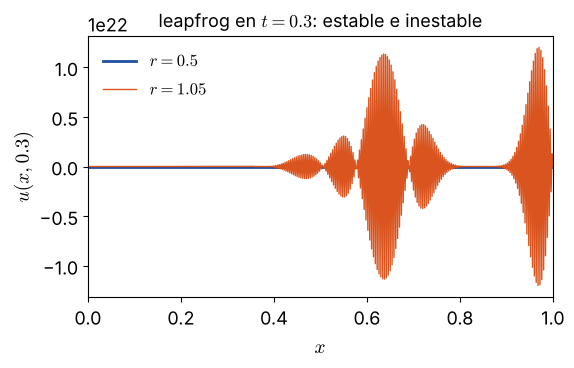

In [14]:
for r in [1.0, 1.05]:
    dt = r * dx / c
    U = numerico.ondas_leapfrog(g_r(xg), h_r(xg), c, dx, dt, int(round(0.7 / dt)))
    print(f"r = c dt/dx = {r}: max |u| en t = " + ", ".join(f"{t:g}: {np.abs(U[int(round(t / dt))]).max():.2e}" for t in [0.1, 0.2, 0.3, 0.4, 0.5, 0.7]))
fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(xg, sol_lf[0.5][1][int(round(0.3 / sol_lf[0.5][0]))], color=COLORES["traj"], lw=2, label="$r = 0.5$")
ax.plot(xg, U[int(round(0.3 / dt))], color=COLORES["modelo"], lw=1, label="$r = 1.05$")
ax.set_xlabel("$x$"); ax.set_ylabel("$u(x, 0.3)$"); ax.set_xlim(0, L); ax.legend(loc="upper left", fontsize=12); ax.set_title("leapfrog en $t = 0.3$: estable e inestable", fontsize=13)
plt.show()

## Para experimentar

1. Repetí la Figura `sol-ondas-20nodos` con el dato triangular de la cuerda pulsada ($x_0 = L/5$): ahora la truncación a $20$ modos no es exacta (fijate el fenómeno de Gibbs cerca del pico) y, por d'Alembert, el pico *viaja* sin suavizarse: mirá $u(\cdot,t)$ en $t = 0.1, 0.2, 0.3$ y contá cuántos picos hay. ¿Cómo se compara con lo que hace la ecuación del calor con el mismo dato?
2. Con la cuerda pulsada, calculá la fracción de energía en cada modo para $x_0 = L/2$, $L/5$ y $L/20$ (cerca del puente) y graficá las tres: ¿cuál suena más "brillante"? Después la cuerda golpeada: $g = 0$ y $h$ un bump angosto en $x_0$; verificá que los $B_k$ decaen como $1/k$.
3. Cambiá el extremo derecho por uno libre ($u_x(L,t) = 0$): en `ondas_leapfrog` eso se impone con un nodo fantasma, `u[n, -1] = u[n, -2]`, o copiando el esquema con $u_{N+1} = u_{N-1}$. ¿Con qué signo se refleja ahora el pulso? ¿Qué extensión (par o impar) hay que usar en d'Alembert para reproducirlo?
4. Agregá amortiguamiento, $u_{tt} + 2\gamma u_t = c^2 u_{xx}$ (fricción con el aire, como en el ejercicio de amortiguamiento de la Sección 21.1), al leapfrog y a la serie (cada modo pasa a ser un oscilador amortiguado, $q_k'' + 2\gamma q_k' + \omega_k^2 q_k = 0$), y mirá cómo decae la energía por modo. ¿Por qué, con $\gamma$ constante, *todos* los modos decaen con la misma tasa $e^{-\gamma t}$? Agregá ahora un término de fricción que crezca con la frecuencia, el viscoelástico: $u_{tt} + 2\gamma u_t - \nu u_{xxt} = c^2 u_{xx}$ con $\nu > 0$. Mostrá que el modo $k$ decae con tasa $\gamma_k = \gamma + \frac{\nu}{2}\bigl(\frac{k\pi}{L}\bigr)^2$, que crece como $k^2$, y que entonces los armónicos altos se apagan antes, como en la cuerda real del laboratorio `lab-cuerda`. ¿Con qué $\nu$ el modo $k$ decae el doble de rápido que el modo $1$?